In [2]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from datetime import datetime, timedelta
import itertools, math
from typing import Iterable, Callable
import importlib
import fx_hedges.fxshort_gates 
import config
import functions2 
import functions1
importlib.reload(fx_hedges.fxshort_gates)
importlib.reload(functions2)
plt.style.use('dark_background')   


window_start = '2025-4-19'
ticker = 'GBPCHF.FOREX'

df = functions1.fetch_csv_robust(ticker=ticker,params=config.params)
s = functions1.sort_cols(df)
s= functions2.standardize_fx_daily_index(s)
s = functions2.trim_series(s, window_start, datetime.now())
print(ticker)
print(s.index[0].date())
print(s.index[-1].date())


GBPCHF.FOREX
2025-04-21
2025-10-10


In [3]:
s = np.array([2,8,2,6,3,7,6,7,1,6,6,3,8,2,2,6,7,8,8,4,3,2,1,5,6,7,8,9,4,3,2,1,5,6,7,8,9])
s = pd.Series(s)

mid = s.rolling(7).mean()

atr = s.rolling(3).apply(lambda x: x.max() - x.min())
# upper = mid + .5 *atr
# lower = mid - .5 *atr
upper = s.rolling(7).max()
lower = s.rolling(7).min()


i 0 h 0 s[i] 2
not a high
set low
i 1 h 0 s[i] 8
set high
i 2 h 8 s[i] 2
not a high
set low
i 3 h 8 s[i] 6
set high nan
i 4 h 8 s[i] 3
not a high
set low nan
i 5 h 8 s[i] 7
set high nan
i 6 h 8 s[i] 6
set high nan
i 7 h 8 s[i] 7
set high nan
i 8 h 8 s[i] 1
not a high
set low
i 9 h 8 s[i] 6
set high nan
i 10 h 8 s[i] 6
set high nan
i 11 h 8 s[i] 3
not a high
set low nan
i 12 h 8 s[i] 8
set high
i 13 h 8 s[i] 2
not a high
set low nan
i 14 h 8 s[i] 2
not a high
set low nan
i 15 h 8 s[i] 6
set high nan
i 16 h 8 s[i] 7
set high nan
i 17 h 8 s[i] 8
set high
i 18 h 8 s[i] 8
set high
i 19 h 8 s[i] 4
not a high
set low nan
i 20 h 8 s[i] 3
not a high
set low nan
i 21 h 8 s[i] 2
not a high
set low nan
i 22 h 8 s[i] 1
not a high
set low
i 23 h 8 s[i] 5
not a high
set low nan
i 24 h 8 s[i] 6
set high nan
i 25 h 8 s[i] 7
set high nan
i 26 h 8 s[i] 8
set high
i 27 h 8 s[i] 9
set high
i 28 h 9 s[i] 4
not a high
set low nan
i 29 h 9 s[i] 3
not a high
set low nan
i 30 h 9 s[i] 2
not a high
set low nan
i

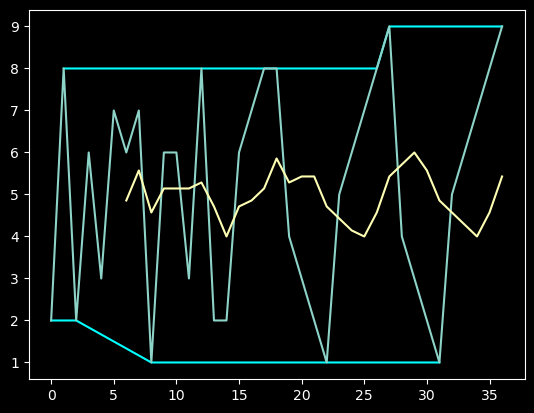

In [4]:
highs = s.copy()
lows = s.copy()
h=0
l=100
for i in s.index:
    print('i', i,'h',h, 's[i]', s[i])
    if s[i] > mid[7]:
        if s[i] >= h:   
            print('set high')
            h = s[i]
            highs[i] = h
        elif s[i] <= h and i != len(s)-1:
            print('set high nan')
            highs[i] = np.nan
        lows[i] = np.nan
    else:
        print('not a high')
        highs[i] = np.nan
        if s[i] <= l:
            print('set low')
            l = s[i]
            lows[i] = s[i]
        else:
            print('set low nan')
            lows[i] = np.nan
    # print('j', j,'l',l, 's[j]', s[j])
print('highs\n', highs)
print('lows\n', lows)
plt.plot(lows.dropna(), color='cyan')
plt.plot(highs.dropna(), color='cyan')
plt.plot(s, label='s')
plt.plot(mid)
# plt.plot(upper)
# plt.plot(lower)
# for i,v in enumerate(atr):
#     plt.text(i, 2, str(v))
plt.show()

In [26]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

def rolling_atr_proxy(s: pd.Series, window: int = 14) -> pd.Series:
    """Mean absolute diff as ATR proxy."""
    return s.diff().abs().rolling(window, min_periods=window).mean()

def atr_stability_ratio(s: pd.Series, short_window: int = 14, long_window: int = 60) -> pd.Series:
    """Ratio of short- to long-term ATR. < 1.3 typically indicates compression."""
    short = rolling_atr_proxy(s, short_window)
    long = rolling_atr_proxy(s, long_window)
    return short / long

In [27]:
def rolling_linreg(s: pd.Series, window: int = 30):
    """Compute rolling slope and R² (fit quality) over given window."""
    X = np.arange(window).reshape(-1, 1)
    slopes, r2s = [], []
    for i in range(len(s)):
        if i < window:
            slopes.append(np.nan)
            r2s.append(np.nan)
            continue
        y = s.iloc[i - window:i].values
        model = LinearRegression().fit(X, y)
        slopes.append(model.coef_[0])
        r2s.append(model.score(X, y))
    slopes = pd.Series(slopes, index=s.index)
    r2s = pd.Series(r2s, index=s.index)
    return slopes, r2s

In [28]:
def identify_channel_regions(
    s: pd.Series,
    atr_ratio_thresh: float = 1.3,
    r2_thresh: float = 0.8,
    slope_thresh: float = 0.001,
    window: int = 30,
):
    """Boolean mask for 'channel-like' behaviour."""
    atr_ratio = atr_stability_ratio(s)
    slopes, r2s = rolling_linreg(s, window)

    in_channel = (
        (atr_ratio < atr_ratio_thresh)
        & (r2s > r2_thresh)
        & (slopes.abs() < slope_thresh)
    )
    return in_channel, atr_ratio, slopes, r2s

In [29]:
def detect_breakouts(s: pd.Series, in_channel: pd.Series, window: int = 20):
    """Detect breakouts after channel periods."""
    upper = s.rolling(window).max()
    lower = s.rolling(window).min()
    breakout_up = (~in_channel) & (s > upper)
    breakout_down = (~in_channel) & (s < lower)
    return breakout_up, breakout_down, upper, lower

In [30]:
import matplotlib.pyplot as plt

def plot_channels_and_breakouts(s, in_channel, breakout_up, breakout_down, upper, lower):
    plt.style.use("dark_background")
    fig, ax = plt.subplots(figsize=(11, 6))
    s.plot(ax=ax, color="steelblue", lw=1.3, label="Price")
    upper.plot(ax=ax, color="gray", lw=0.8, ls="--", alpha=0.5)
    lower.plot(ax=ax, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.scatter(s.index[in_channel], s[in_channel], color="lime", s=10, label="Channel")
    ax.scatter(s.index[breakout_up], s[breakout_up], color="red", s=30, label="Break ↑")
    ax.scatter(s.index[breakout_down], s[breakout_down], color="cyan", s=30, label="Break ↓")
    ax.legend(loc="upper left")
    ax.set_title("Channel and Breakout Detection")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>)

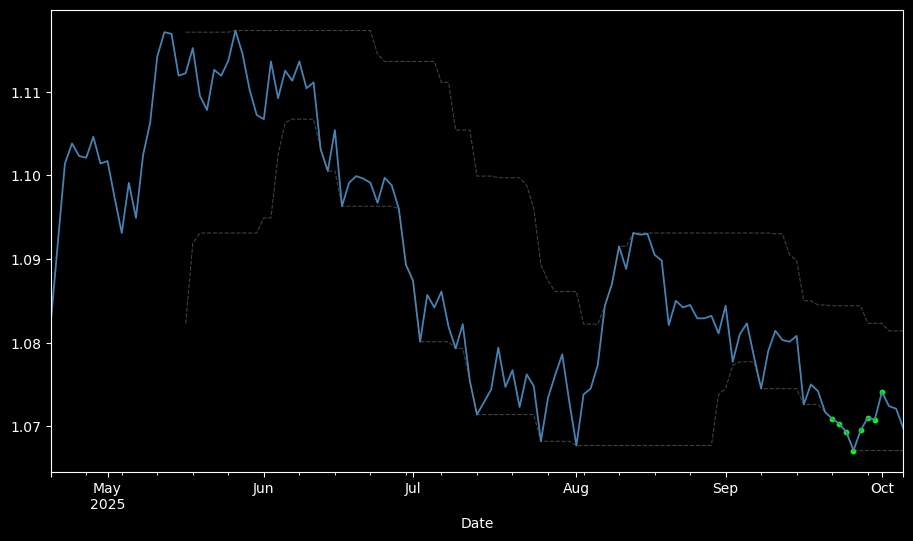

In [32]:
in_channel, atr_ratio, slopes, r2s = identify_channel_regions(s)
break_up, break_down, upper, lower = detect_breakouts(s, in_channel)
plot_channels_and_breakouts(s, in_channel, break_up, break_down, upper, lower)